<a href="https://colab.research.google.com/github/kanezadjorda/UTS-BASIS-DATA-6C-BIS/blob/main/UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 pip install google-play-scraper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00


In [2]:
!pip install google-play-scraper

import os
from google_play_scraper import reviews, Sort
import csv

app_id = 'id.qoin.korlantas.user'
result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=200,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'
file_path = os.path.join(os.getcwd(), filename)

try:
    with open(file_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
        writer.writeheader()
        for review in result:
            writer.writerow({
                'userName': review['userName'],
                'score': review['score'],
                'at': review['at'],
                'content': review['content']
            })
    print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")
    if os.path.exists(file_path):
        print(f"Verifikasi: File '{filename}' berhasil dibuat di: {file_path}")
    else:
        print(f"Peringatan: File '{filename}' TIDAK DITEMUKAN setelah upaya penyimpanan!")
except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan ulasan ke '{filename}': {e}")

Berhasil menyimpan 200 ulasan ke 'ulasan_google_play.csv'
Verifikasi: File 'ulasan_google_play.csv' berhasil dibuat di: /content/ulasan_google_play.csv


In [3]:
pip install transformers

In [4]:
import pandas as pd
from transformers import pipeline

# Load the CSV file into a pandas DataFrame
df_reviews = pd.read_csv('ulasan_google_play.csv')

Sekarang, kita akan menginisialisasi pipeline untuk analisis sentimen. Karena ulasan dalam bahasa Indonesia, saya akan menggunakan model yang telah dilatih untuk bahasa Indonesia jika tersedia, atau model multilingual jika tidak.

In [5]:
# Initialize a sentiment analysis pipeline
# Using a multilingual model that supports Indonesian
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Selanjutnya, kita akan menerapkan analisis sentimen pada kolom 'content' dari DataFrame ulasan dan menampilkan hasilnya.

In [6]:
print(f"DataFrame contains {len(df_reviews)} rows.")
print("Menampilkan 10 baris pertama untuk verifikasi:")
display(df_reviews.head(10))

DataFrame contains 200 rows.
Menampilkan 10 baris pertama untuk verifikasi:


,userName,score,at,content
0,Loedi Ratrianto,5,2026-04-30 07:13:30,Aplikasinya berjalan lancar meskipun saya mela...
1,Adi Gendut,5,2026-04-30 07:03:15,Sangat membantu dan mudah dengan adannya digit...
2,Nanank Qohar,3,2026-04-30 06:51:49,pengajuan SIM A dan C sejak tgl 21 April kenap...
3,Chintia Aprilliyani,5,2026-04-30 06:39:37,sangat membantu saya dalam memperpanjang SIM
4,Al RaFa OnLiNe ShOP,5,2026-04-30 05:56:22,aplikasi yang sangat membantu makasih korlanta...
5,Ibad khalid عبادالرحمن خالد,5,2026-04-30 05:28:23,Thank you very much to digital korlantas polri
6,faisal alfian,3,2026-04-30 05:01:52,fitur pada aplikasi mesti mengunduh aplikasi d...
7,alek hermanto,1,2026-04-30 04:20:52,"Saya selalu gagal dapat OTP, sms selalu tidak ..."
8,Eka Permadi,5,2026-04-30 04:03:36,cocok untuk yg sibuk perpanjangan sim online
9,Setro Magono,4,2026-04-30 03:26:43,"Q lok,"


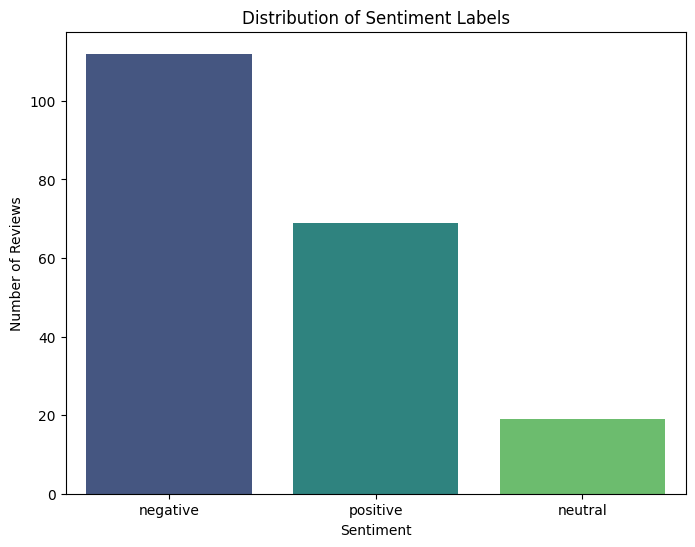

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- FIX: Apply sentiment analysis to create the 'sentiment' column ---
df_reviews['sentiment'] = df_reviews['content'].apply(lambda x: sentiment_pipeline(x)[0]['label'])
df_reviews['sentiment_score'] = df_reviews['content'].apply(lambda x: sentiment_pipeline(x)[0]['score'])
# ----------------------------------------------------------------------

# Calculate the distribution of sentiment labels
sentiment_counts = df_reviews['sentiment'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', hue=sentiment_counts.index, legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()